In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
# Download the small NLTK data packages for tokenizing, stopwords, and lemmatization
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ANAMIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ANAMIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ANAMIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ANAMIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ANAMIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# STEP 1: Load Dataset

In [5]:

# Load the original AG News training and testing datasets
train_df = pd.read_csv(r"D:\Users\ANAMIKA\Documents\IIIT\AVG\train.csv")
test_df = pd.read_csv(r"D:\Users\ANAMIKA\Documents\IIIT\AVG\test.csv")

In [8]:
print("Training Data")
print(train_df.head())

print("\nTesting Data")
print(test_df.head())

Training Data
   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  \
0  Reuters - Short-sellers, Wall Street's dwindli...   
1  Reuters - Private investment firm Carlyle Grou...   
2  Reuters - Soaring crude prices plus worries\ab...   
3  Reuters - Authorities have halted oil export\f...   
4  AFP - Tearaway world oil prices, toppling reco...   

                                                text  
0  Wall St. Bears Claw Back Into the Black (Reute...  
1  Carlyle Looks Toward Commercial Aerospace (Reu...  
2  Oil and Economy Cloud Stocks' Outlook (Reuters...  
3  Iraq Halts 

In [9]:
# Mapping numeric class labels to category names
CLASS_MAP = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

In [10]:
# Combine Title and Description into a single text column
train_df["text"] = (
    train_df["Title"].astype(str) + " " + train_df["Description"].astype(str)
)

test_df["text"] = (
    test_df["Title"].astype(str) + " " + test_df["Description"].astype(str)
)

In [11]:
# Convert numeric labels into category names
train_df["category"] = train_df["Class Index"].map(CLASS_MAP)
test_df["category"] = test_df["Class Index"].map(CLASS_MAP)

In [12]:
# Keep only the required columns
train_df = train_df[["text", "category"]]
test_df = test_df[["text", "category"]]

In [13]:
# Remove any missing values (if present)
train_df = train_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

In [14]:
# Display size
print("Training Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)

Training Dataset Shape: (120000, 2)
Test Dataset Shape: (7600, 2)


In [15]:
print("\nTraining Category Distribution:")
print(train_df["category"].value_counts())


Training Category Distribution:
category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


In [17]:
# Display the first five rows
train_df.head(10)

,text,category
0,Wall St. Bears Claw Back Into the Black (Reute...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,"Oil prices soar to all-time record, posing new...",Business
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",Business
6,Money Funds Fell in Latest Week (AP) AP - Asse...,Business
7,Fed minutes show dissent over inflation (USATO...,Business
8,Safety Net (Forbes.com) Forbes.com - After ear...,Business
9,Wall St. Bears Claw Back Into the Black NEW Y...,Business


# STEP 2: Text Cleaning

In [24]:
import re

def clean_text(text):
    """
    Cleans the input text by:
    1. Converting to lowercase.
    2. Removing URLs.
    3. Removing punctuation and numbers.
    4. Removing extra spaces.
    """

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [25]:
# Apply text cleaning to both datasets
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [26]:
# Display original vs cleaned text
comparison = pd.DataFrame({
    "Original Text": train_df["text"].head(5),
    "Cleaned Text": train_df["clean_text"].head(5)
})

comparison

,Original Text,Cleaned Text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook reuters r...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...
4,"Oil prices soar to all-time record, posing new...",oil prices soar to all time record posing new ...


# STEP 3: Tokenization

In [27]:
def tokenize(text):
    """Split cleaned text into a list of word tokens."""
    return word_tokenize(text)

In [31]:
# Apply tokenization on both
train_df["tokens"] = train_df["clean_text"].apply(tokenize)
test_df["tokens"] = test_df["clean_text"].apply(tokenize)


In [34]:
#Display te first dew tokenize articles
train_df[["clean_text", "tokens"]].head()


,clean_text,tokens
0,wall st bears claw back into the black reuters...,"[wall, st, bears, claw, back, into, the, black..."
1,carlyle looks toward commercial aerospace reut...,"[carlyle, looks, toward, commercial, aerospace..."
2,oil and economy cloud stocks outlook reuters r...,"[oil, and, economy, cloud, stocks, outlook, re..."
3,iraq halts oil exports from main southern pipe...,"[iraq, halts, oil, exports, from, main, southe..."
4,oil prices soar to all time record posing new ...,"[oil, prices, soar, to, all, time, record, pos..."


In [35]:
train_df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,wall st bears claw back into the black reuters...,"[wall, st, bears, claw, back, into, the, black..."
1,carlyle looks toward commercial aerospace reut...,"[carlyle, looks, toward, commercial, aerospace..."
2,oil and economy cloud stocks outlook reuters r...,"[oil, and, economy, cloud, stocks, outlook, re..."
3,iraq halts oil exports from main southern pipe...,"[iraq, halts, oil, exports, from, main, southe..."
4,oil prices soar to all time record posing new ...,"[oil, prices, soar, to, all, time, record, pos..."


# STEP 4: StopWord Removal

In [ ]:
# Function to remove stopwords
def remove_stopwords(tokens):
    """
    Removes common English stopwords from a list of tokens.
    """
    filtered_tokens = [
        word for word in tokens
        if word not in stop_words
    ]
    return filtered_tokens

# Apply stopword removal
train_df["filtered_tokens"] = train_df["tokens"].apply(remove_stopwords)
test_df["filtered_tokens"] = test_df["tokens"].apply(remove_stopwords)

# Compare before and after
comparison = pd.DataFrame({
    "Before": train_df["tokens"].head(5),
    "After": train_df["filtered_tokens"].head(5)
})

comparison

In [36]:
def remove_stopwords(tokens):
    """Remove common English stopwords."""
    return [t for t in tokens if t not in STOP_WORDS]


In [38]:
# Apply stopword removal
train_df["filtered_tokens"] = train_df["tokens"].apply(remove_stopwords)
test_df["filtered_tokens"] = test_df["tokens"].apply(remove_stopwords)


In [ ]:
# Compare before and after
comparison = pd.DataFrame({
    "Before": train_df["tokens"].head(5),
    "After": train_df["filtered_tokens"].head(5)
})

comparison

,Before,After
0,"[wall, st, bears, claw, back, into, the, black...","[wall, st, bears, claw, back, black, reuters, ..."
1,"[carlyle, looks, toward, commercial, aerospace...","[carlyle, looks, toward, commercial, aerospace..."
2,"[oil, and, economy, cloud, stocks, outlook, re...","[oil, economy, cloud, stocks, outlook, reuters..."
3,"[iraq, halts, oil, exports, from, main, southe...","[iraq, halts, oil, exports, main, southern, pi..."
4,"[oil, prices, soar, to, all, time, record, pos...","[oil, prices, soar, time, record, posing, new,..."


# STEP 5: Lemmatization

In [45]:
# FUnction to Lemmatize Tokens
def lemmatize(tokens):
    """Reduce each token to its dictionary root form."""
    return [LEMMATIZER.lemmatize(t) for t in tokens]

In [46]:
# Apply lemmatization
train_df["lemmatized_tokens"] = train_df["filtered_tokens"].apply(lemmatize)
test_df["lemmatized_tokens"] = test_df["filtered_tokens"].apply(lemmatize)


In [47]:
# Compare before and after
comparison = pd.DataFrame({
    "Before": train_df["filtered_tokens"].head(5),
    "After": train_df["lemmatized_tokens"].head(5)
})

comparison

,Before,After
0,"[wall, st, bears, claw, back, black, reuters, ...","[wall, st, bear, claw, back, black, reuters, r..."
1,"[carlyle, looks, toward, commercial, aerospace...","[carlyle, look, toward, commercial, aerospace,..."
2,"[oil, economy, cloud, stocks, outlook, reuters...","[oil, economy, cloud, stock, outlook, reuters,..."
3,"[iraq, halts, oil, exports, main, southern, pi...","[iraq, halt, oil, export, main, southern, pipe..."
4,"[oil, prices, soar, time, record, posing, new,...","[oil, price, soar, time, record, posing, new, ..."


In [48]:
# Convert token lists back into sentences
train_df["processed_text"] = train_df["lemmatized_tokens"].apply(lambda words: " ".join(words))
test_df["processed_text"] = test_df["lemmatized_tokens"].apply(lambda words: " ".join(words))

In [49]:
train_df[["text", "clean_text", "category"]].head(10)

,text,clean_text,category
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook reuters r...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...,Business
4,"Oil prices soar to all-time record, posing new...",oil prices soar to all time record posing new ...,Business
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",stocks end up but near year lows reuters reute...,Business
6,Money Funds Fell in Latest Week (AP) AP - Asse...,money funds fell in latest week ap ap assets o...,Business
7,Fed minutes show dissent over inflation (USATO...,fed minutes show dissent over inflation usatod...,Business
8,Safety Net (Forbes.com) Forbes.com - After ear...,safety net forbes com forbes com after earning...,Business
9,Wall St. Bears Claw Back Into the Black NEW Y...,wall st bears claw back into the black new yor...,Business


## STEP 6: TF-IDF Vectorization

In [50]:
# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))

In [51]:
# Learn vocabulary from training data and transform it
X_train = vectorizer.fit_transform(train_df["clean_text"])

# Transform test data using the same vocabulary
X_test = vectorizer.transform(test_df["clean_text"])

In [52]:
# Target labels
y_train = train_df["category"]
y_test = test_df["category"]

In [55]:
# Display information
print("Training Feature Matrix Shape :", X_train.shape)
print("Testing Feature Matrix Shape  :", X_test.shape)
print("Number of Features            :", len(vectorizer.get_feature_names_out()))

Training Feature Matrix Shape : (120000, 20000)
Testing Feature Matrix Shape  : (7600, 20000)
Number of Features            : 20000


# STEP 7: Train-Test Split

In [56]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 120000
Testing samples:  7600


# STEP 8: Train MOodel

In [57]:
# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


# STEP 9: Prediction

In [58]:
# Predict categories for the test dataset
y_pred = model.predict(X_test)


In [59]:
# Display some sample predictions
results = pd.DataFrame({
    "text": test_df["text"].values,
    "Actual": y_test.values,
    "Predicted": y_pred
})
results.head(10)

,text,Actual,Predicted
0,Fears for T N pension after talks Unions repre...,Business,Business
1,The Race is On: Second Private Team Sets Launc...,Sci/Tech,Sci/Tech
2,Ky. Company Wins Grant to Study Peptides (AP) ...,Sci/Tech,Sci/Tech
3,Prediction Unit Helps Forecast Wildfires (AP) ...,Sci/Tech,Sports
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,Sci/Tech,Sci/Tech
5,Open Letter Against British Copyright Indoctri...,Sci/Tech,Sci/Tech
6,"Loosing the War on Terrorism \\""Sven Jaschan, ...",Sci/Tech,Sci/Tech
7,"FOAFKey: FOAF, PGP, Key Distribution, and Bloo...",Sci/Tech,Sci/Tech
8,E-mail scam targets police chief Wiltshire Pol...,Sci/Tech,Sci/Tech
9,"Card fraud unit nets 36,000 cards In its first...",Sci/Tech,Sci/Tech


# STEP 10: Model Evaluation

In [60]:
# Calculate the accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc * 100:.2f}%\n")

# Display Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 91.61%

Classification Report:
              precision    recall  f1-score   support

    Business       0.89      0.88      0.89      1900
    Sci/Tech       0.89      0.90      0.90      1900
      Sports       0.95      0.98      0.96      1900
       World       0.93      0.90      0.92      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



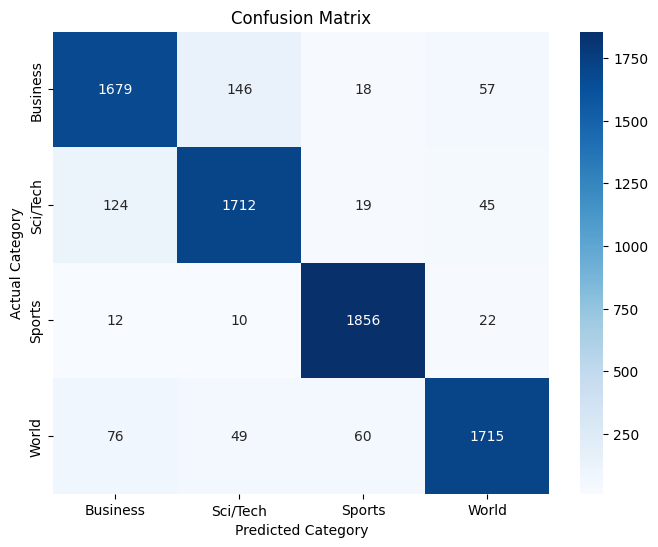

In [63]:
# Generate the confusion matrix
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.show()

# Custom News Headline Prediction

In [64]:
def predict_headline(headline):
    """
    Predict the category of a custom news headline.
    """

    # Apply the same preprocessing used during training
    cleaned = clean_text(headline)
    tokens = tokenize(cleaned)
    filtered = remove_stopwords(tokens)
    lemmatized = lemmatize(filtered)
    processed_text = " ".join(lemmatized)

    # Convert text into TF-IDF features
    vector = vectorizer.transform([processed_text])

    # Predict category
    prediction = model.predict(vector)[0]

    return prediction

In [66]:
print("=" * 60)
print("Custom News Category Prediction")
print("Type 'exit' to quit.")
print("=" * 60)

while True:

    headline = input("\nEnter a news headline: ")

    if headline.lower() == "exit":
        print("\nThank you for using the News Classifier!")
        break

    predicted_category = predict_headline(headline)

    print(f"Predicted Category: {predicted_category}")

Custom News Category Prediction
Type 'exit' to quit.
Predicted Category: Sports

Thank you for using the News Classifier!
